# Dependency Parsing with U-DepPLLaMA (Google Colab / T4)

This notebook runs the fine-tuned LLaMA-2 model from [U-DepPLLaMA](https://www.ai-lc.it/wp-content/uploads/2024/08/IJCOL_10_1_2_hromei_et_al.pdf) to perform Universal Dependency parsing as sequence-to-sequence generation, on a free/standard **Colab T4 GPU**.

The pipeline is:

1. Feed a raw sentence to the LLM through a fixed prompt template (`### Input: ... ### Answer:`).
2. The model generates a bracketed tree string such as `[ROOT[NSUBJ[He ]] [AUX [was ]] ...]`.
3. The bracketed string is decoded back into CoNLL-U style rows (`id`, `form`, `head`, `deprel`) using the helpers shipped in the repo's `sentence_utils.py`.
4. The resulting dependency tree is rendered as a table and as a graph.

**Before running:** set `Runtime > Change runtime type > Hardware accelerator > T4 GPU`.

**Also required:** a Hugging Face account with access granted to the gated `meta-llama/Llama-2-13b-hf` weights (request access on the model page, then log in below).

T4 has ~15GB VRAM. A 4-bit quantized 13B model needs ~8-10GB, which fits, but it is tight with beam search — if you hit an out-of-memory error, lower `num_beams` to 1 in the generation config cell.

## 1. Check the GPU

In [21]:
!nvidia-smi

Wed Sep 30 20:52:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             31W /   70W |   14457MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Install dependencies

Colab already ships a compatible `torch` build with CUDA support, so we install only the extra packages on top of it (rather than reusing the repo's `requirements.txt`, which pins an older `torch==...+cu118` wheel and an old `bitsandbytes` that can fail to auto-detect CUDA outside a hand-built environment).

In [22]:
%pip install -q -U bitsandbytes accelerate peft "transformers>=4.38" torchao conllu

For Displaying Chinese

In [ ]:
import matplotlib.font_manager as fm

_CJK_CANDIDATES = [
    "Noto Sans CJK SC", "Noto Sans CJK JP", "Noto Sans CJK TC", "Noto Sans CJK KR",
    "WenQuanYi Zen Hei", "Droid Sans Fallback", "Microsoft YaHei", "SimHei",
]
_known_fonts = {f.name for f in fm.fontManager.ttflist}
_cjk_font = next((name for name in _CJK_CANDIDATES if name in _known_fonts), None)

if _cjk_font is None:
    # matplotlib's default font (DejaVu Sans) has no CJK glyphs, so labels render
    # as empty boxes. Install Noto's CJK fonts (Colab runs as root, so no sudo
    # needed) and register them with matplotlib's font manager.
    import subprocess
    subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-noto-cjk"], capture_output=True)
    for path in fm.findSystemFonts():
        if "NotoSansCJK" in path or "NotoSerifCJK" in path:
            fm.fontManager.addfont(path)
    _known_fonts = {f.name for f in fm.fontManager.ttflist}
    _cjk_font = next((name for name in _CJK_CANDIDATES if name in _known_fonts), None)

if _cjk_font:
    plt.rcParams["font.sans-serif"] = [_cjk_font, "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False
    print(f"Using '{_cjk_font}' for CJK-capable plot labels.")
else:
    print("No CJK-capable font found/installed; Chinese/Japanese/Korean labels may render as boxes.")

Using 'Noto Sans CJK JP' for CJK-capable plot labels.


## 3. Clone the repository

Colab runtimes are ephemeral, so we clone the repo fresh to get `sentence_utils.py` (bracket <-> CoNLL-U conversion) and `deppllama_utils.py` (prompt template).

In [23]:
import os

REPO_URL = "https://github.com/paulhjwu/u-deppllama.git"
REPO_BRANCH = "exp1"
REPO_DIR = "/content/u-deppllama"

if os.path.isdir(os.path.join(REPO_DIR, ".git")):
    !git -C {REPO_DIR} fetch --no-tags {REPO_URL} {REPO_BRANCH}
    !git -C {REPO_DIR} merge --ff-only FETCH_HEAD
elif not os.path.exists(REPO_DIR):
    !git clone --branch {REPO_BRANCH} {REPO_URL} {REPO_DIR}
else:
    raise RuntimeError(f"{REPO_DIR} exists but is not a Git checkout; remove it and rerun this cell.")

%cd {REPO_DIR}

From https://github.com/paulhjwu/u-deppllama
 * branch            exp1       -> FETCH_HEAD
Already up to date.
/content/u-deppllama


In [24]:
import sys
from pathlib import Path

repo_path = str(Path(REPO_DIR).resolve())
if repo_path in sys.path:
    sys.path.remove(repo_path)
sys.path.insert(0, repo_path)

# Ensure these modules are loaded from REPO_DIR, even if imported earlier.
for module_name in ("sentence_utils", "deppllama_utils"):
    sys.modules.pop(module_name, None)

import torch
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from transformers import BitsAndBytesConfig, AutoModelForCausalLM, AutoTokenizer, GenerationConfig
from peft import PeftModel

# sentence_utils parses CLI arguments at import time; hide notebook arguments.
_orig_argv = sys.argv
try:
    sys.argv = [_orig_argv[0]]
    import sentence_utils
finally:
    sys.argv = _orig_argv

import deppllama_utils

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

import torch
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from transformers import BitsAndBytesConfig, AutoModelForCausalLM, AutoTokenizer, GenerationConfig
from peft import PeftModel

# Repository utilities have already been imported above.


## 4. Hugging Face authentication

`meta-llama/Llama-2-13b-hf` is gated — request access on its model page with the same account, then run this cell and paste a token (with at least `read` scope).

In [25]:
from huggingface_hub import notebook_login
notebook_login()

## 5. Load the base model, the LoRA adapter, and the tokenizer

This mirrors the snippet from the repo's README: the LLaMA-2-13B base model is loaded in 4-bit precision (via `bitsandbytes`) and the `U-DepPLLaMA` LoRA adapter is applied on top with `peft`.

Note: the README example uses `bnb_4bit_compute_dtype=torch.bfloat16`, but T4 (Turing architecture) has no native bfloat16 support — we use `torch.float16` instead, which T4 supports natively.

In [26]:
BASE_MODEL = "meta-llama/Llama-2-13b-hf"
ADAPTER = "sag-uniroma2/u-depp-llama-2-13b"

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=quant_config,
    torch_dtype=torch.float16,
    trust_remote_code=True,
    device_map={"": 0},
)
model = PeftModel.from_pretrained(model, ADAPTER)
model.eval()

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
if tokenizer.pad_token is None:
    # LLaMA-2's tokenizer has no pad token by default, but we need one for
    # batched/padded tokenization in generate_parse_string below.
    tokenizer.pad_token = tokenizer.eos_token

generation_config = GenerationConfig(
    num_beams=4,  # lower to 1 (greedy) if you hit an out-of-memory error on T4
    do_sample=False,
    early_stopping=True,
)

Loading weights:   0%|          | 0/363 [00:00<?, ?it/s]

## 6. Generate the bracketed parse for a sentence

The model is prompted with `deppllama_utils.generate_prompt_pred`, which is the exact same template used at training time.

In [27]:
def generate_parse_string(sentence, max_new_tokens=1024):
    prompt = deppllama_utils.generate_prompt_pred(sentence)
    inputs = tokenizer(prompt, return_tensors="pt", padding=True, truncation=True, max_length=512)
    input_ids = inputs["input_ids"].to(model.device)

    with torch.no_grad():
        gen_outputs = model.generate(
            input_ids=input_ids,
            generation_config=generation_config,
            return_dict_in_generate=True,
            output_scores=True,
            max_new_tokens=max_new_tokens,
            use_cache=True,
        )
    decoded = tokenizer.decode(gen_outputs.sequences[0], skip_special_tokens=True)
    return decoded.split("### Answer:")[1].strip()

In [ ]:
# sentence = "我 到了 所定 的 日期，必 按 正直 施行 審判。"
# sentence = "珍惜 今天 所 能"
sentence = "Mavaango-a ki kailx-en tu wai kata"
bracket_output = generate_parse_string(sentence)
print(bracket_output)

[transformers] Both `max_new_tokens` (=1024) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[root[珍惜][obj[nmod[今天]][mark[所]][能]]]


## 7. Decode the bracketed string into a dependency tree

`sentence_utils.get_decode` turns the bracket string back into `{id, form, head, deprel}` rows. The released checkpoint was trained on the `grct` (Grammatical-Relation-Centered Tree) representation, which is what produces the `[DEPREL[form ]]` nesting shown in the README (e.g. `[ROOT[NSUBJ[He ]] ...]`). Use `"lct"` or `"loct"` instead if you are decoding output from a model trained with a different representation.

In [42]:
REPRESENTATION = "grct"

def decode_to_rows(bracket_string, representation_type=REPRESENTATION):
    rows = sentence_utils.get_decode(bracket_string, representation_type)
    return [rows[i] for i in sorted(rows.keys())]

def rows_to_dataframe(rows):
    return pd.DataFrame(
        [{"id": r["id"], "form": r["form"], "head": int(r["toid"]), "deprel": r["deprel"]} for r in rows]
    )

def to_conllu(rows):
    return "\n".join(sentence_utils.print_line(r) for r in rows)

rows = decode_to_rows(bracket_output)
df = rows_to_dataframe(rows)
df

,id,form,head,deprel
0,1,珍惜,0,root
1,2,今天,4,nmod
2,3,所,4,mark
3,4,能,1,obj


In [43]:
print(to_conllu(rows))

1	珍惜	_	_	_	_	0	root	_	_
2	今天	_	_	_	_	4	nmod	_	_
3	所	_	_	_	_	4	mark	_	_
4	能	_	_	_	_	1	obj	_	_


## 8. Visualize the dependency tree

/tmp/ipykernel_10030/3548999342.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


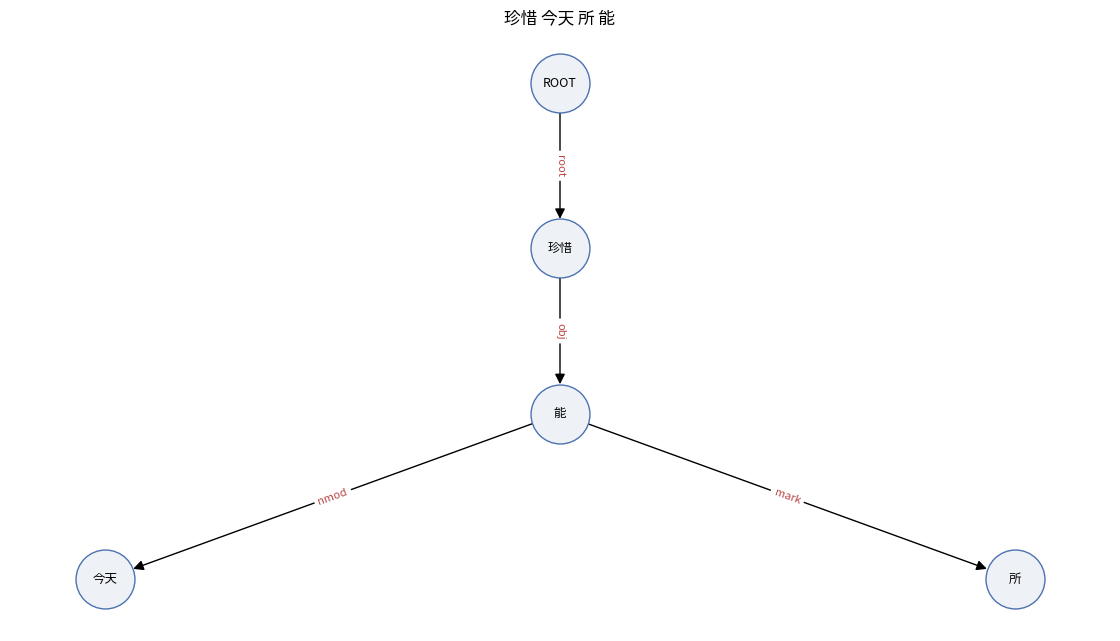

In [45]:
def hierarchy_pos(G, root, width=1.0, vert_gap=0.2, vert_loc=0, xcenter=0.5):
    """Simple tree layout: assigns x by in-order leaf position, y by depth."""

    def _next_x(counter=[0]):
        counter[0] += 1
        return counter[0]

    leaves_x = {}

    def assign_x(node, visited):
        visited.add(node)
        children = [c for c in G.successors(node) if c not in visited]
        if not children:
            leaves_x[node] = _next_x()
            return leaves_x[node]
        xs = [assign_x(c, visited) for c in children]
        leaves_x[node] = sum(xs) / len(xs)
        return leaves_x[node]

    assign_x(root, set())

    pos = {}

    def assign_y(node, depth, visited):
        visited.add(node)
        pos[node] = (leaves_x[node], -depth * vert_gap + vert_loc)
        for c in G.successors(node):
            if c not in visited:
                assign_y(c, depth + 1, visited)

    assign_y(root, 0, set())
    return pos


def visualize_tree(df, sentence=None, figsize=(11, 6)):
    G = nx.DiGraph()
    G.add_node(0, label="ROOT")
    for _, row in df.iterrows():
        G.add_node(row["id"], label=row["form"])
    for _, row in df.iterrows():
        G.add_edge(row["head"], row["id"], label=row["deprel"])

    try:
        pos = hierarchy_pos(G, root=0)
    except Exception:
        pos = nx.spring_layout(G, seed=23)

    labels = nx.get_node_attributes(G, "label")
    edge_labels = nx.get_edge_attributes(G, "label")

    plt.figure(figsize=figsize)
    nx.draw(
        G, pos, labels=labels, with_labels=True,
        node_color="#eef2f7", edgecolors="#4c72b0", node_size=1800,
        font_size=9, arrows=True, arrowsize=15,
    )
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color="#b44", font_size=8)
    if sentence:
        plt.title(sentence)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


visualize_tree(df, sentence=sentence)

## 9. End-to-end helper for batches of sentences

In [ ]:
def parse_sentence(sentence, representation_type=REPRESENTATION, plot=True):
    bracket_string = generate_parse_string(sentence)
    rows = decode_to_rows(bracket_string, representation_type)
    df = rows_to_dataframe(rows)
    if plot:
        visualize_tree(df, sentence=sentence)
    return bracket_string, df


sentences = [
    "The quick brown fox jumps over the lazy dog.",
    "She decided to study linguistics because she loves languages.",
]

results = {}
for s in sentences:
    bracket_string, df_s = parse_sentence(s)
    results[s] = df_s

## Notes

- The `U-DepPLLaMA` checkpoint used here was fine-tuned across **26 languages** from Universal Dependencies, so `parse_sentence` can be called on non-English input as well.
- Other checkpoints (different sizes / representations) may be available under the [sag-uniroma2](https://huggingface.co/sag-uniroma2) Hugging Face organization; swap `ADAPTER` and `REPRESENTATION` accordingly.
- If the model output cannot be fully decoded (e.g. truncated generation), `sentence_utils.get_decode` may raise or return a partial tree — increase `max_new_tokens` or inspect the raw `bracket_output` string first.
- If you see a CUDA out-of-memory error on T4, restart the runtime (`Runtime > Restart session`) and re-run with `generation_config.num_beams = 1`.